# IT25103993 — Hansaka K. L. G. S.
## Individual Preprocessing Task: Handling Missing Data
**Dataset:** Chronic Kidney Disease (UCI ML Repository, id 336)
**Group:** 2026-Y2-S1-KU-56

This notebook demonstrates my individually assigned preprocessing technique — **handling missing values** — applied to the CKD dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')

df = pd.read_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103993_missing_handled.csv')
print("Shape:", df.shape)
df.head()

Shape: (399, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


### Why this technique is needed for this dataset
The CKD dataset (400 patient records, 24 clinical features + class label) was collected in a real hospital setting,
and lab tests are frequently skipped for individual patients. As a result almost every column has missing
values (marked `?` in the original ARFF file, which we already converted to `NaN` when building
`ckd_clean_raw.csv`). Missing data must be resolved before any model can be trained, since algorithms such as
SVM or Neural Networks cannot accept `NaN` inputs.

In [ ]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': missing_counts, 'missing_%': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_%
rbc,152,38.1
rbcc,131,32.8
wbcc,106,26.6
pot,88,22.1
sod,87,21.8
pcv,71,17.8
pc,65,16.3
hemo,52,13.0
su,49,12.3
sg,47,11.8


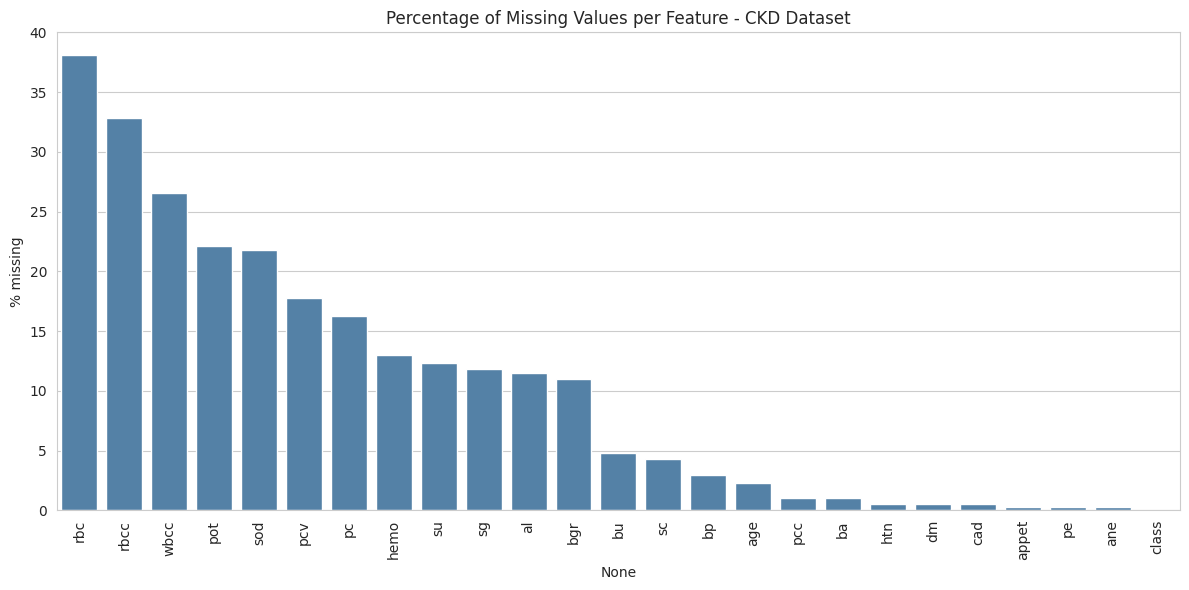

In [ ]:
# EDA Visualization 1: Missing value pattern across all features
plt.figure(figsize=(12,6))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_%'], color='steelblue')
plt.xticks(rotation=90)
plt.ylabel('% missing')
plt.title('Percentage of Missing Values per Feature - CKD Dataset')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103993_missing_values_barplot.png', dpi=120)
plt.show()

**Interpretation:** Red blood cell count (`rbc`), red blood cell count numeric (`rbcc`) and white blood
cell count (`wbcc`) have the highest proportion of missing values (over 25%), which matches how these are
less routinely ordered lab tests compared to basic ones like `age` or `bp`. No column is missing more than
~38%, so dropping rows is not appropriate (we would lose most of the 399 records) — imputation is the right
strategy here.

In [ ]:
numeric_cols = ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc']
categorical_cols = ['sg','al','su','rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']

df_imputed = df.copy()

# Numeric columns: median imputation (robust to the outliers/skew present in lab values)
for col in numeric_cols:
    median_val = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median_val)

# Categorical columns: mode (most frequent category) imputation
for col in categorical_cols:
    mode_val = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_val)

print("Missing values remaining:", df_imputed.isna().sum().sum())
df_imputed.isna().sum()

Missing values remaining: 0


,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0
bgr,0


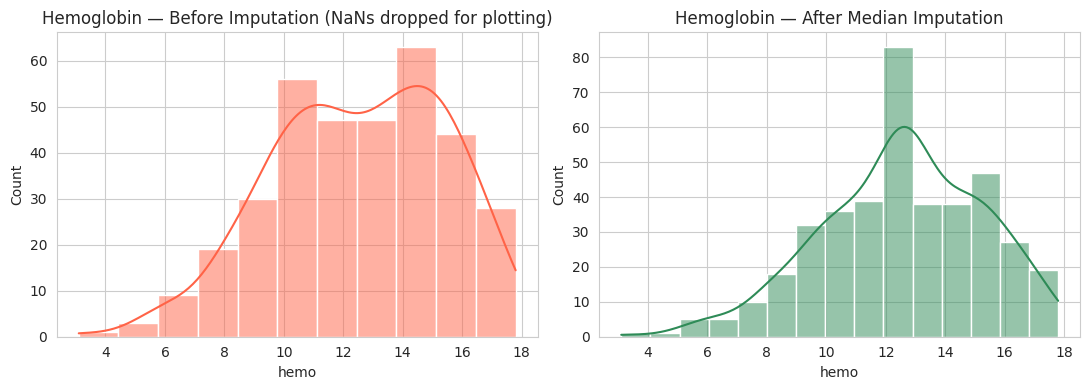

In [ ]:
# Before vs after comparison for one numeric column as evidence of correct imputation
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.histplot(df['hemo'].dropna(), kde=True, ax=axes[0], color='tomato')
axes[0].set_title('Hemoglobin — Before Imputation (NaNs dropped for plotting)')
sns.histplot(df_imputed['hemo'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Hemoglobin — After Median Imputation')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103993_hemoglobin_before_after_imputation.png', dpi=120)
plt.show()

**Interpretation:** The overall shape/spread of the hemoglobin distribution is preserved after
imputation — median imputation only adds a spike of values at the median rather than distorting the
distribution, which is why it is preferable to mean imputation on this slightly skewed clinical variable.

In [ ]:
df_imputed.to_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103993_missing_handled.csv', index=False)
print("Saved cleaned (no-missing-values) dataset for downstream use by the group pipeline.")

Saved cleaned (no-missing-values) dataset for downstream use by the group pipeline.


### Summary
- **Technique:** Missing value imputation (median for 11 numeric features, mode for 13 categorical features).
- **Justification:** Real clinical data has irregular test ordering; dropping rows/columns would discard too
  much information (up to 38% missing on some columns), so imputation preserves sample size (399 records) while
  still handling the `NaN`s.
- **Output:** `results/outputs/IT25103993_missing_handled.csv` — 0 missing values remaining, feeds into the
  group's combined pipeline.